# MF結果と検出傾きの重ね描き

MF alpha画像の上に、検出された3種類の傾き方向を重ねて表示します。

- `0.9775`: 細い高alpha線に対応する方向
- `1.2664`: 太いalphaバイアスに対応する方向
- `2.5575`: 急な傾きの広域成分として検出された方向

入力する `.npy` を変えれば、補正前MF、補正後MF、全体画像結果にも同じ図を作れます。

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display


# ============================================================
# User settings
# ============================================================

# Change this to the MF result you want to show.
# Examples:
#   D:/research/code/outputs_roi_fixed_full_image_slopes_stats_sweep/baseline_no_destripe_alpha_corrected.npy
#   D:/research/code/outputs_paper_sensor_geometry_destripe/baseline_no_destripe_alpha_corrected.npy
#   D:/research/code/outputs_paper_sensor_geometry_destripe/paper_sensor_line_then_column_each_iter_angle125_focus_alpha_corrected.npy
ALPHA_NPY = Path(
    r"D:/research/code/outputs_paper_sensor_geometry_destripe/"
    r"baseline_no_destripe_alpha_corrected.npy"
)
OUTPUT_DIR = Path(r"D:/research/code/figures_slope_overlay")
OUTPUT_BASENAME = "mf_alpha_detected_slope_guides"

# Slopes are in image coordinates:
#   row = slope * col + intercept
SLOPE_GUIDES = [
    {
        "label": "thin high-alpha line",
        "slope": 0.9775,
        "color": "#e41a1c",
        "linestyle": "-",
    },
    {
        "label": "broad alpha bias",
        "slope": 1.2664,
        "color": "#377eb8",
        "linestyle": "-",
    },
    {
        "label": "steep broad component",
        "slope": 2.5575,
        "color": "#4daf4a",
        "linestyle": "-",
    },
]

# Draw one central line plus several parallel guide lines for each slope.
N_PARALLEL_LINES_EACH_SIDE = 2
LINE_SEPARATION_AS_IMAGE_FRACTION = 0.18

FIGSIZE = (13, 6)
DPI = 220


In [9]:
# ============================================================
# Plot helpers
# ============================================================

def robust_limits(arr: np.ndarray, valid: np.ndarray | None = None, q=(2, 98)) -> tuple[float, float]:
    values = np.asarray(arr, dtype=float)
    if valid is not None:
        values = values[np.asarray(valid, dtype=bool)]
    else:
        values = values.ravel()
    values = values[np.isfinite(values)]
    if values.size == 0:
        return -1.0, 1.0
    lo, hi = np.nanpercentile(values, q)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        med = float(np.nanmedian(values))
        spread = float(np.nanstd(values)) or 1.0
        lo, hi = med - spread, med + spread
    return float(lo), float(hi)


def line_segments_for_slope(height: int, width: int, slope: float, intercept: float) -> tuple[np.ndarray, np.ndarray]:
    xs = np.linspace(0, width - 1, max(width, 2))
    ys = slope * xs + intercept
    ok = (ys >= 0) & (ys <= height - 1)
    return xs[ok], ys[ok]


def representative_intercepts(height: int, width: int, slope: float) -> list[float]:
    center_col = 0.5 * (width - 1)
    center_row = 0.5 * (height - 1)
    center_intercept = center_row - slope * center_col

    separation = LINE_SEPARATION_AS_IMAGE_FRACTION * min(height, width)
    norm = np.sqrt(1.0 + slope * slope)
    intercept_step = separation * norm
    offsets = range(-N_PARALLEL_LINES_EACH_SIDE, N_PARALLEL_LINES_EACH_SIDE + 1)
    return [center_intercept + k * intercept_step for k in offsets]


def add_slope_guides(ax, height: int, width: int, guides: list[dict]) -> None:
    for guide in guides:
        slope = float(guide["slope"])
        angle = np.degrees(np.arctan(slope))
        intercepts = representative_intercepts(height, width, slope)
        for i, intercept in enumerate(intercepts):
            xs, ys = line_segments_for_slope(height, width, slope, intercept)
            if xs.size < 2:
                continue
            is_center = i == len(intercepts) // 2
            ax.plot(
                xs,
                ys,
                color=guide["color"],
                linestyle=guide.get("linestyle", "-"),
                linewidth=2.4 if is_center else 1.2,
                alpha=0.95 if is_center else 0.45,
                label=(
                    f"{guide['label']}: slope={slope:.4f}, angle={angle:.1f} deg"
                    if is_center
                    else None
                ),
            )


def make_slope_legend_panel(ax, guides: list[dict]) -> None:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title("Detected slope directions")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    x0, x1 = 0.12, 0.88
    y0 = 0.18
    for i, guide in enumerate(guides):
        slope = float(guide["slope"])
        angle = np.degrees(np.arctan(slope))
        y_center = y0 + 0.26 * i
        xs = np.array([x0, x1])
        ys = y_center + 0.22 * slope / max(abs(slope), 1.0) * (xs - xs.mean())
        ax.plot(xs, ys, color=guide["color"], linewidth=3.0)
        ax.text(
            0.05,
            y_center + 0.085,
            f"{guide['label']}\nslope={slope:.4f}, angle={angle:.1f} deg",
            color=guide["color"],
            fontsize=10,
            va="bottom",
        )


def plot_mf_alpha_with_slope_guides(alpha_path: Path, output_dir: Path, basename: str) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    alpha = np.load(alpha_path)
    valid = np.isfinite(alpha)
    height, width = alpha.shape
    vmin, vmax = robust_limits(alpha, valid=valid)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=FIGSIZE,
        gridspec_kw={"width_ratios": [1.35, 0.8]},
        constrained_layout=True,
    )

    im = axes[0].imshow(alpha, origin="upper", cmap="viridis", vmin=vmin, vmax=vmax)
    axes[0].set_title("MF alpha with detected slope guides")
    axes[0].set_xlabel("col / x")
    axes[0].set_ylabel("row / y")
    add_slope_guides(axes[0], height, width, SLOPE_GUIDES)
    axes[0].legend(loc="upper left", fontsize=8, frameon=True, facecolor="white", framealpha=0.8)
    plt.colorbar(im, ax=axes[0], fraction=0.046, label="MF alpha")

    make_slope_legend_panel(axes[1], SLOPE_GUIDES)

    png_path = output_dir / f"{basename}.png"
    pdf_path = output_dir / f"{basename}.pdf"
    fig.savefig(png_path, dpi=DPI)
    fig.savefig(pdf_path)
    plt.show()
    return png_path


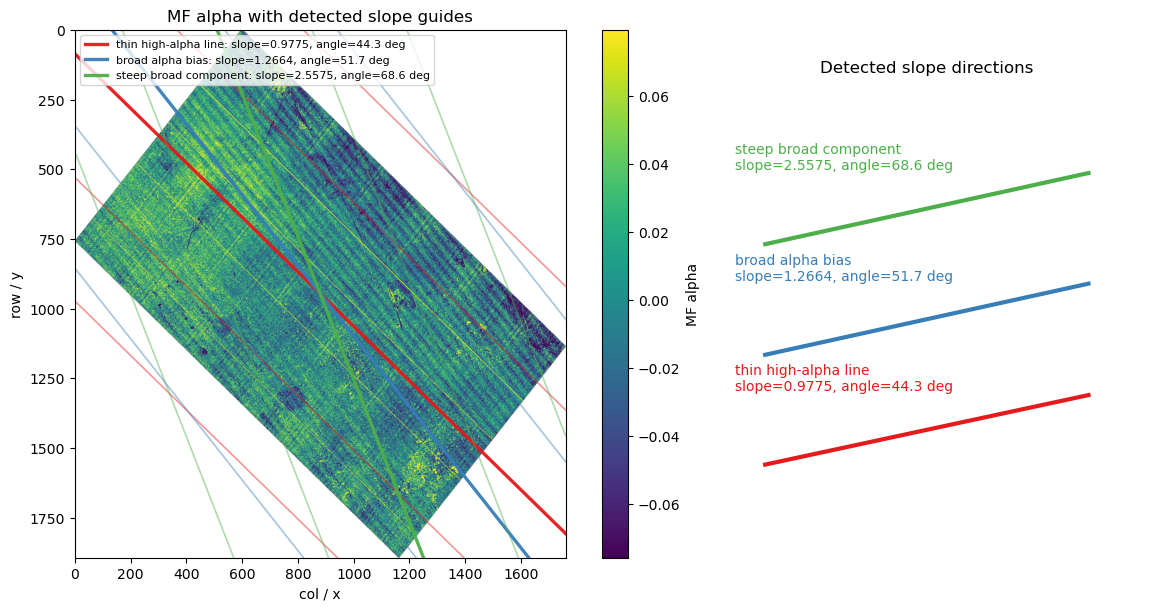

Saved: D:\research\code\figures_slope_overlay\mf_alpha_detected_slope_guides.png
Saved: D:\research\code\figures_slope_overlay\mf_alpha_detected_slope_guides.pdf


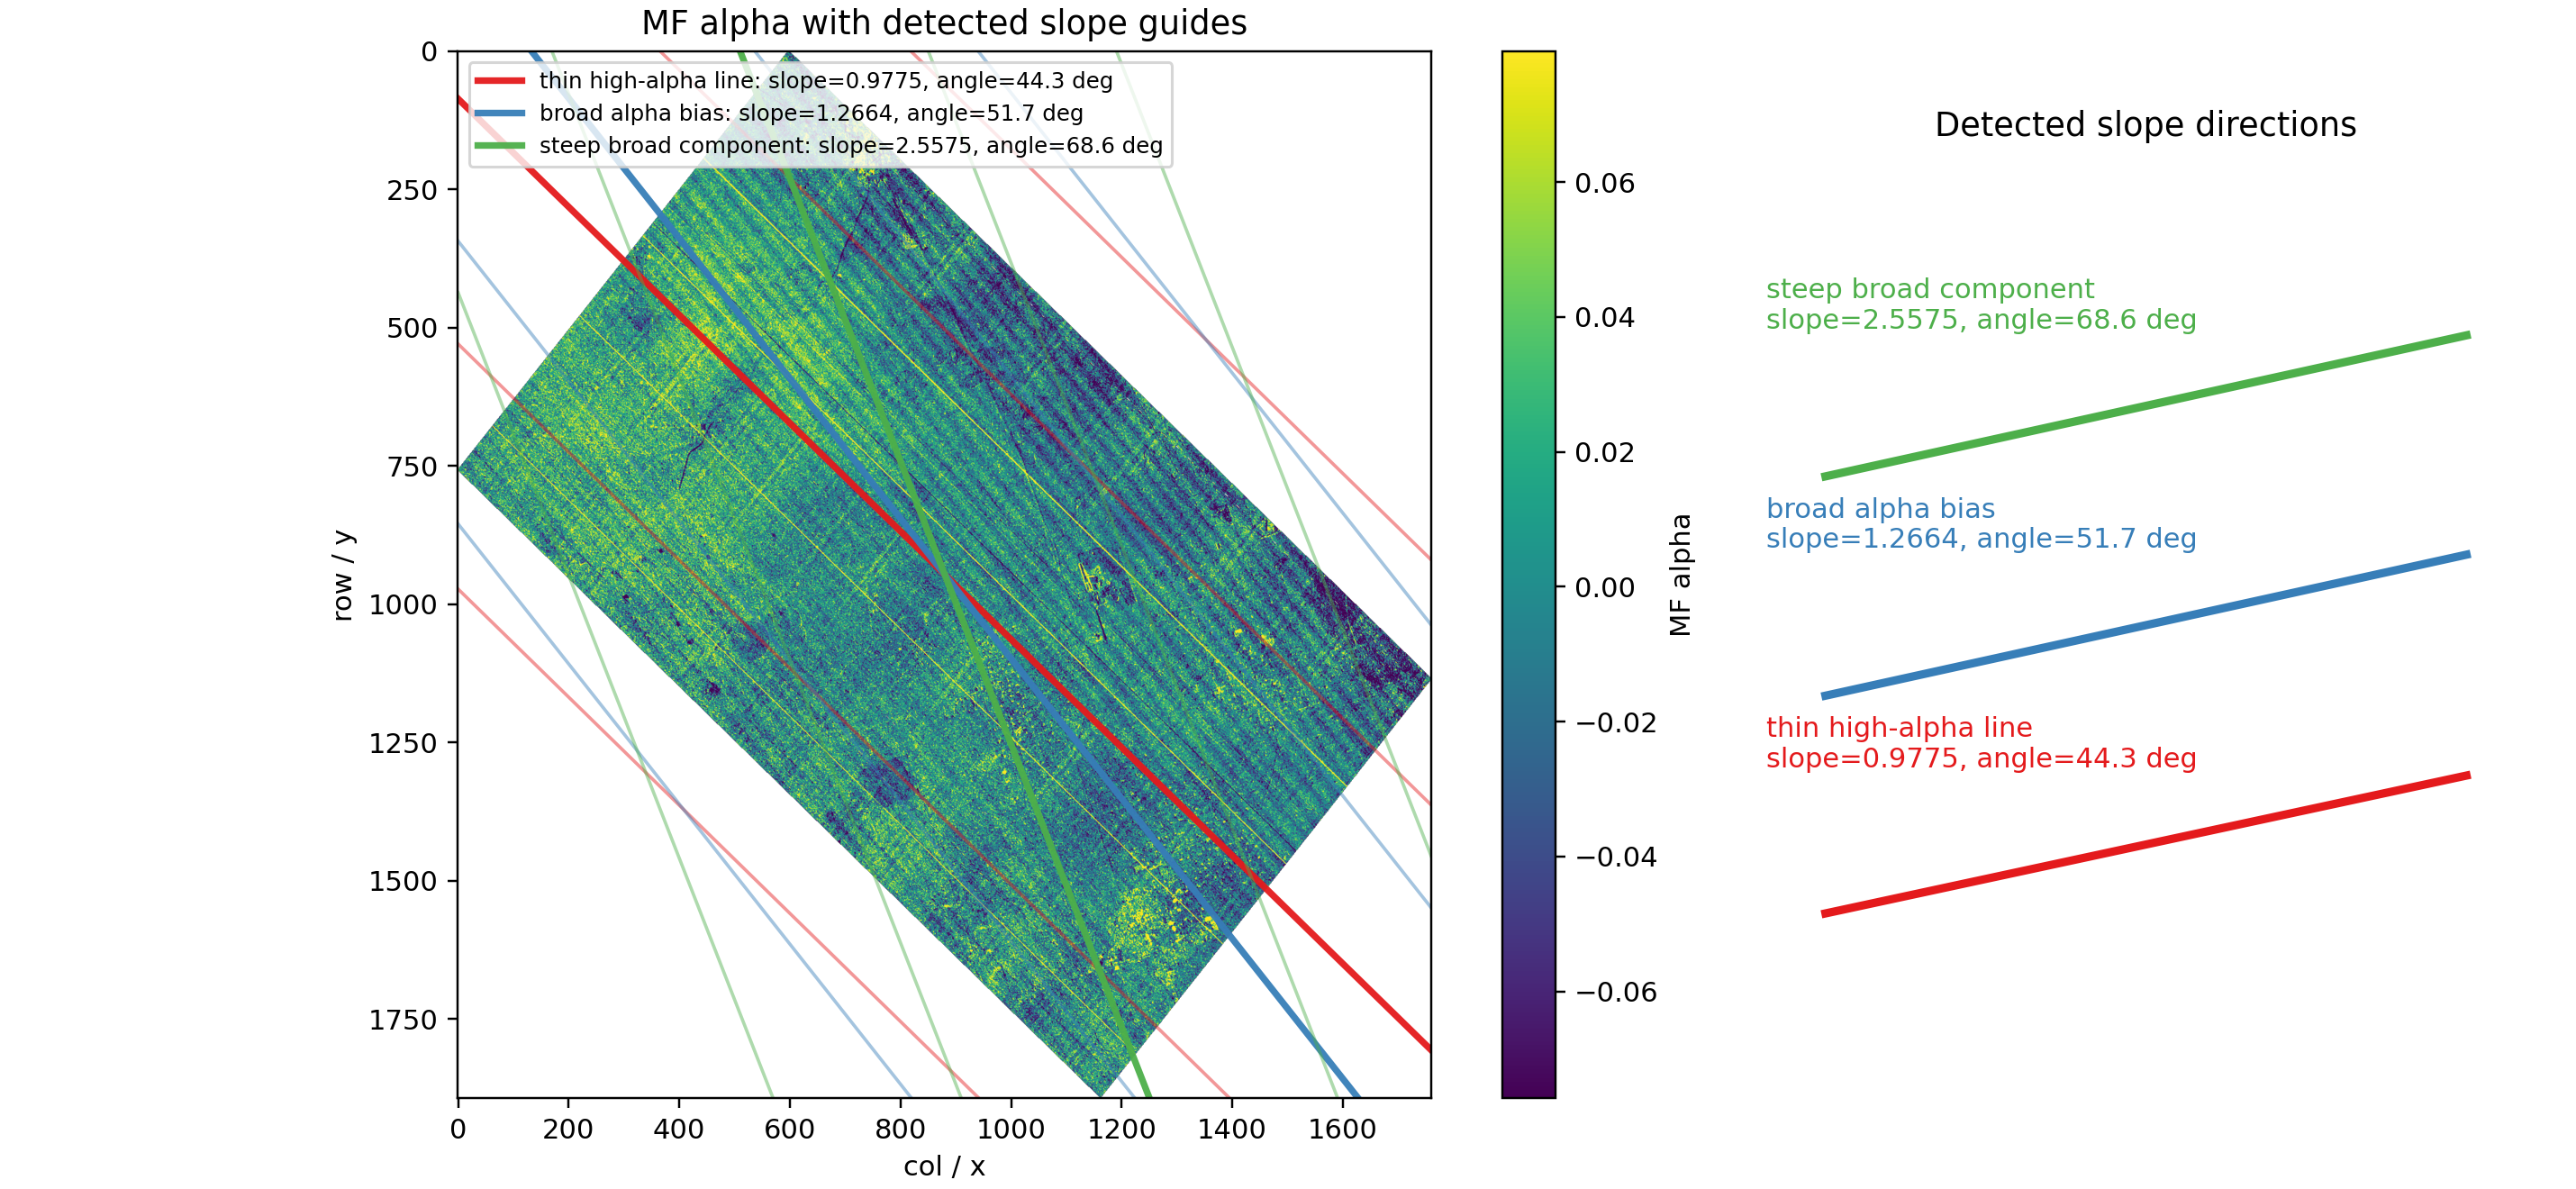

In [10]:
png_path = plot_mf_alpha_with_slope_guides(ALPHA_NPY, OUTPUT_DIR, OUTPUT_BASENAME)
print(f"Saved: {png_path}")
print(f"Saved: {png_path.with_suffix('.pdf')}")
display(Image(filename=str(png_path)))
